# This notebook shows how to compute optical matrix elements, circular dichroism and Kubo-form quantum geometry
### Import the necessary libraries

In [1]:
%matplotlib inline
import re
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure
from elkpy.parsers import optical

### The momentum (velocity) matrix element
Between two second-variational eigenstates at the same $k$-point,
$$ p^a_{nm} = \langle\psi_n|\left(-i\nabla + \tfrac{1}{4c^2}\left[\vec{\sigma}\times\nabla V_s\right]\right)_a|\psi_m\rangle $$
with $V_s$ the Kohn-Sham potential and the second term the spin-orbit correction. For a local $V_s$ in atomic units this is also the velocity operator, $\hat{\mathbf{v}}=\hat{\mathbf{p}}$, so its diagonal is the band velocity $\partial E_n/\partial\mathbf{k}$ and its off-diagonal elements are the optical dipole matrix elements.

In [2]:
# Bohr, monolayer h-BN (a=2.51 Angstrom) with 20 Bohr of vacuum
A, VACUUM = 4.743210000, 20.0
HBN_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, VACUUM)]
HBN_SPECIES = {"B": [(1 / 3, 2 / 3, 0.5)], "N": [(2 / 3, 1 / 3, 0.5)]}

hbn = Structure(HBN_AVEC, HBN_SPECIES).get_calculation(
    "_scratch/hbn_optical", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0,
    extra_blocks={"nempty": [12]},  # empty states for the Kubo sums below to run over
)
hbn.get_energy()

-79.111157810347

### Occupied-band count
From `EIGVAL.OUT`'s own occupation numbers, not an assumed electron count -- core electrons are not among the valence bands `nstsv` indexes at all.

In [3]:
first_block = (hbn.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 1.0 for o in occ)  # valence-band-top index
ist1

4

### Valley-selective circular dichroism
Circularly polarized light couples through $P_\pm = p^x_{cv} \pm i\,p^y_{cv}$, so the transition's degree of circular polarization is
$$ \eta(\mathbf{k}) = \frac{|P_+|^2-|P_-|^2}{|P_+|^2+|P_-|^2} $$
$\eta=+1$ absorbs $\sigma^+$ light only, $\eta=-1$ only $\sigma^-$. The three-fold rotation symmetry at the zone corner forces $|\eta|=1$ there, and time reversal makes the two inequivalent valleys opposite: $\eta(K')=-\eta(K)$ (Yao, Xiao & Niu, PRB 77, 235406 (2008); Xiao, Liu, Feng, Xu & Yao, PRL 108, 196802 (2012)).

In [4]:
def segment(a, b, n):
    a, b = np.array(a), np.array(b)
    return [tuple(a + (b - a) * t) for t in np.linspace(0, 1, n)]

G, K, M = (0, 0, 0), (1 / 3, 1 / 3, 0), (0.5, 0, 0)
# K' as the periodic image (2/3, -1/3, 0), so the path hugs the BZ boundary
# instead of cutting through the interior near Gamma
Kp = (2 / 3, -1 / 3, 0)
segments = [segment(G, K, 9)] + [segment(a, b, 9)[1:] for a, b in [(K, M), (M, Kp), (Kp, G)]]
ticks = np.concatenate([[0], np.cumsum([len(s) for s in segments]) - 1])
path = sum(segments, [])

efermi = float((hbn.workdir / "EFERMI.OUT").read_text().split()[0])
ha = 27.211386  # Hartree -> eV

energies, eta, curvature = [], [], []
with hbn.eigenstate_session() as session:
    for k in path:
        m = session.momentum(k)  # energies AND p^a_nm from ONE diagonalisation
        energies.append(m.energies[ist1 - 3 : ist1 + 3])
        # band-edge transition only: both edges are non-degenerate here, and lumping
        # in another band would average distinct selectivities and dilute eta
        eta.append(optical.circular_polarization(m.pmat, ist1, ist1 + 1)["eta"])
        curvature.append(optical.kubo_berry_curvature(m.energies, m.pmat, 1, ist1))
energies = (np.array(energies) - efermi) * ha
eta, curvature = np.array(eta), np.array(curvature)

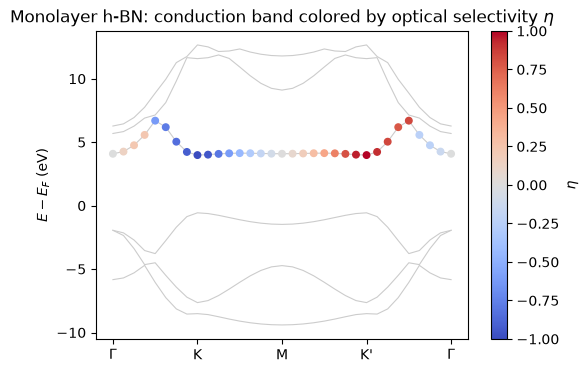

In [5]:
x = np.arange(len(path))
fig, ax = plt.subplots(figsize=(6, 4))
for band in range(energies.shape[1]):
    ax.plot(x, energies[:, band], color="0.8", linewidth=0.8, zorder=1)
# color the conduction band by the selectivity of ITS transition from the valence top
sc = ax.scatter(x, energies[:, 3], c=eta, cmap="coolwarm", vmin=-1, vmax=1, s=22, zorder=2)
ax.set_xticks(ticks)
ax.set_xticklabels([r"$\Gamma$", "K", "M", "K'", r"$\Gamma$"])
ax.set_ylabel(r"$E-E_F$ (eV)")
fig.colorbar(sc, ax=ax, label=r"$\eta$")
ax.set_title(r"Monolayer h-BN: conduction band colored by optical selectivity $\eta$")
plt.show()

### Quantum geometry without a $k$-derivative
Perturbation theory turns $|\partial_a u\rangle$ into a sum over states, so the same velocity matrix elements give the quantum geometric tensor directly. With
$$ T_{ab} = \sum_{n\in W}\sum_{m\notin W} \frac{\langle n|v_a|m\rangle\langle m|v_b|n\rangle}{(\varepsilon_n-\varepsilon_m)^2} $$
the metric is $g_{ab}=\mathrm{Re}\,T_{ab}$ and the Berry curvature is $F_{ab}=-2\,\mathrm{Im}\,T_{ab}$. This is an independent route to the quantity `get_berry_curvature_path()` computes from wavefunction overlaps, so the two disagree only through the truncation of the state sum (set by `nempty`).

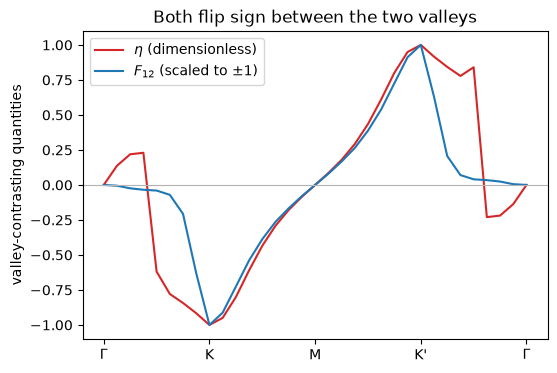

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, eta, color="C3", label=r"$\eta$ (dimensionless)")
ax.plot(x, curvature / np.abs(curvature).max(), color="C0",
        label=r"$F_{12}$ (scaled to $\pm1$)")
ax.axhline(0, color="0.7", linewidth=0.8)
ax.set_xticks(ticks)
ax.set_xticklabels([r"$\Gamma$", "K", "M", "K'", r"$\Gamma$"])
ax.set_ylabel("valley-contrasting quantities")
ax.legend()
ax.set_title("Both flip sign between the two valleys")
plt.show()